In [40]:
import drawsvg as draw
import numpy as np

In [41]:
# generate vertices

def dist3d(p1, p2):
    return np.sqrt( (p1[0] - p2[0]) ** 2 + (p1[1] - p2[1]) ** 2 + (p1[2] - p2[2]) ** 2 )

def flatY(dx, d):
    return np.sqrt(np.abs((d ** 2) - (dx ** 2)))


# y^2 / B^2 + z^2 / H^2 = 1 {z >= 0, x^2 <= y^2, y >= 0 }
# y^2 + (z^2 * B^2) / H^2 = B^2

# z = sqrt(H^2 - (y^2 * H^2)/(B^2))
# x1 = y
# x2 = -y
# y in [0, B]

# shape generation

# 3 mm
thickness = 3
# 0.1 mm
kerf = 0.1

# CM
T = 15
B = 60
b = (B-T)

H = 30

# Add to mesh
y = 0

verts = []
flatverts = []

maxy = 0

step = 2
i = 0
last = False
while True:

    # calculate z
    z = np.sqrt(H ** 2 - ((y ** 2) * (H ** 2))/((b/2) ** 2))
    x1 = y + T/2
    x2 = -y - T/2
    y1 = y
    
    # vertices
    v1 = (x1, y1, z)
    v2 = (x2, y1, z)
    
    verts.append(v1)
    verts.append(v2)
    
    # flattening
    # doesn't work
    if y > 0:
        fv1 = flatverts[-2]
        
        d1 = dist3d(verts[-4], v1)
        
        fy = flatY(v1[0] - fv1[0], d1)
        
        fv3 = (x1, fv1[1] + fy, 0)
        fv4 = (x2, fv1[1] + fy, 0)
        
        flatverts.append(fv3)
        flatverts.append(fv4)
        
    else:
        fv1 = (x1, y1, 0)
        fv2 = (x2, y1, 0)
        flatverts.append(fv1)
        flatverts.append(fv2)
    
    maxy = max(maxy, flatverts[-1][1])

    # increment
    y += step
    step = step * 0.92
    if y >= b/2:
        if last:
            break
        else:
            last = True
            y = b/2
    i += 1
    
    if i > 100000:
        break

print(b)
print(verts[0], verts[1], verts[-2], verts[-1])
print(flatverts[0], flatverts[1], flatverts[-2], flatverts[-1])
print(len(flatverts))
print(maxy)

45
(7.5, 0, 30.0) (-7.5, 0, 30.0) (30.0, 22.5, 0.0) (-30.0, 22.5, 0.0)
(7.5, 0, 0) (-7.5, 0, 0) (30.0, 41.436520250921426, 0) (-30.0, 41.436520250921426, 0)
58
41.436520250921426


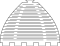

In [42]:
# constants
toothw = 6
toothh = thickness
dovetopw = 8
dovebottomw = 4
doveh = 2

# make drawing
d = draw.Drawing(B, maxy + doveh + toothh + kerf * 4, (- B/2, -(doveh + kerf * 2)))

p = draw.Path(stroke_width="hairline", stroke="black", fill="none", style="vector-effect:non-scaling-stroke;")

# right side
# top to bottom
for vi in range(0, len(flatverts), 2):
    v = flatverts[vi]
    if vi == 0:
        p.M(v[0], v[1])
    else:
        p.L(v[0], v[1])

topy = 0
bottomy = maxy

centerx = 0

topleft = flatverts[1][0]
topright = flatverts[0][0]

bottomleft = flatverts[-1][0]
bottomright = flatverts[-2][0]

# bottom side, with teeth
# from right to left

teeth = (B // toothw) // 2

teethplusgaps = (teeth + teeth-1)

outsidegap = ((bottomright - bottomleft) - (teethplusgaps * toothw))/2

p.L((bottomright - outsidegap) + kerf*2, bottomy)

for i in range(teeth):
    p.v(toothh + kerf*2)
    p.h(-(toothw + kerf*4))
    p.v(-(toothh + kerf*2))
    if i != teeth - 1:
        p.h(-(toothw - kerf*4))

# left side
# bottom to top
for vi in range(len(flatverts) - 1, 0, -2):
    v = flatverts[vi]
    p.L(v[0], v[1])
    maxy = max(maxy, v[1])

# top side, with dovetail
# from left to right
p.L(centerx - dovebottomw/2 - kerf * 2, topy)
p.L(centerx - dovetopw/2 - kerf * 4, topy - doveh - kerf * 2)
p.H(centerx + dovetopw/2 + kerf * 4)
p.L(centerx + dovebottomw/2 + kerf * 2, topy)

# regoin left top with right top
p.Z()

# done with outline
d.append(p)

# stripes
gap = 2.5
innergap = 1.5
y = gap
step = 1.5
vi = 0
i = 0
while y < maxy - gap:
    while vi < len(flatverts) and flatverts[vi][1] < y:
        vi += 2
    if vi >= len(flatverts):
        break
    
    # left
    v1 = flatverts[vi]
    # right
    v2 = flatverts[vi + 1]

    # below left
    v3 = flatverts[vi-2]
    # below right
    v4 = flatverts[vi-1]

    x1 = (y - v2[1])/(v4[1] - v2[1]) * (v4[0] - v2[0]) + v2[0]
    x4 = (y - v1[1])/(v3[1] - v1[1]) * (v3[0] - v1[0]) + v1[0]

    center = (x1 + x4) / 2
    x2 = center - innergap
    x3 = center + innergap

    leftcenter = (x1 + center) / 2
    rightcenter = (x4 + center) / 2

    if i % 2 == 0:
        x1 += gap
        x2 = rightcenter - innergap
        x3 = rightcenter + innergap
    else:
        x4 -= gap
        x2 = leftcenter - innergap
        x3 = leftcenter + innergap

    p = draw.Path(stroke_width="hairline", stroke="black", fill="none", style="vector-effect:non-scaling-stroke;")
    p.M(x1, y)
    p.H(x2)
    d.append(p)
    
    
    p = draw.Path(stroke_width="hairline", stroke="black", fill="none", style="vector-effect:non-scaling-stroke;")
    p.M(x3, y)
    p.H(x4)
    d.append(p)

    y += step
    i += 1

d.svg_args["width"] = f"{d.width}mm"
d.svg_args["height"] = f"{d.height}mm"
d.save_svg("1.svg")
d.save_png("1.png")

d.set_render_size(w=400)
d

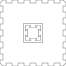

In [43]:
# top of vault
d = draw.Drawing(B + thickness * 2, B + thickness * 2, "center")

p = draw.Path(stroke_width="hairline", stroke="black", fill="none", style="vector-effect:non-scaling-stroke;")
center = 0
top = center - T/2
bottom = center + T/2
left = center - T/2
right = center + T/2
# top left corner

p.M(left, top)
# top edge
p.H(center - dovebottomw/2)
p.L(center - dovetopw/2, top + doveh)
p.H(center + dovetopw/2)
p.L(center + dovebottomw/2, top)
p.L(right, top)

# right edge
p.V(center - dovebottomw/2)
p.L(right - doveh, center - dovetopw/2)
p.V(center + dovetopw/2)
p.L(right, center + dovebottomw/2)
p.L(right, bottom)

# bottom edge
p.H(center + dovebottomw/2)
p.L(center + dovetopw/2, bottom - doveh)
p.H(center - dovetopw/2)
p.L(center - dovebottomw/2, bottom)
p.L(left, bottom)

# left edge
p.L(left, center + dovebottomw/2)
p.L(left + doveh, center + dovetopw/2)
p.V(center - dovetopw/2)
p.L(left, center - dovebottomw/2)

p.Z()

d.append(p)

# bottom of vault
# TEETH
p = draw.Path(stroke_width="hairline", stroke="black", fill="none", style="vector-effect:non-scaling-stroke;")

top = center - B/2 - thickness
bottom = center + B/2 + thickness
left = center - B/2 - thickness
right = center + B/2 + thickness

# top side
p.M(left + thickness, top)

p.h(outsidegap)

for i in range(teeth):
    p.v(toothh)
    p.h(toothw)
    p.v(-toothh)
    if i != teeth - 1:
        p.h(toothw)

p.L(right - thickness, top)

# right side
p.L(right, top + thickness)
p.v(outsidegap)

for i in range(teeth):
    p.h(-toothh)
    p.v(toothw)
    p.h(toothh)
    if i != teeth - 1:
        p.v(toothw)

p.L(right, bottom - thickness)

# bottom side
p.L(right - thickness, bottom)

p.h(-outsidegap)

for i in range(teeth):
    p.v(-toothh)
    p.h(-toothw)
    p.v(toothh)
    if i != teeth - 1:
        p.h(-toothw)

p.L(left + thickness, bottom)

# left side
p.L(left, bottom - thickness)
p.v(-outsidegap)

for i in range(teeth):
    p.h(toothh)
    p.v(-toothw)
    p.h(-toothh)
    if i != teeth - 1:
        p.v(-toothw)

p.L(left, top + thickness)

p.Z()

d.append(p)

# square around bottom
p = draw.Path(stroke_width="hairline", stroke="black", fill="none", style="vector-effect:non-scaling-stroke;")

margin = 2

top = center - T/2 - margin
bottom = center + T/2 + margin
left = center - T/2 - margin
right = center + T/2 + margin

p.M(left, top)
p.L(right, top)
p.L(right, bottom)
p.L(left, bottom)
p.Z()

d.append(p)

d.svg_args["width"] = f"{d.width}mm"
d.svg_args["height"] = f"{d.height}mm"

# export
d.save_svg("2.svg")
d.save_png("2.png")
d.set_render_size(w=400)

d